In [10]:
from typing import Tuple, List, Dict, Any, Optional
import numpy as np
from matplotlib import pyplot as plt
import torch
from tensorboard.notebook import display

In [168]:
def gaussian_curve_numpy(
    dt: float, length: float, max_height: float = 1.0, sigma: float = 0.05
) -> np.ndarray:
    """
    Creates a Gaussian distribution that spans the specified length.

    Args:
        dt: Time step size
        length: Total duration of the Gaussian curve
        max_height: Maximum height of the curve at the peak
        sigma: Standard deviation of the Gaussian (controls width)

    Returns:
        Curve values as numpy array
    """
    # Create time points
    t = np.arange(0, length + dt, dt, dtype=np.float32)

    # Center the Gaussian at the end of the length
    mean = length / 2.0

    # Create Gaussian shape
    y = max_height * np.exp(-0.5 * ((t - mean) / sigma) ** 2)

    return y


def calculate_beat_times_with_noise(
    period: float,
    n_pulses: int,
    phase_noise_std: float,
    jitter_std: float,
    random_start_offset: float,
) -> Tuple[List[float], List[float], List[float]]:
    """
    Calculate beat times with phase noise and jitter.

    Args:
        period: Base period between beats
        n_pulses: Number of pulses
        phase_noise_std: Standard deviation for phase noise
        jitter_std: Standard deviation for jitter
        random_start_offset: Random offset before first beat (negative value)

    Returns:
        beat_times: Final beat times including all noise
        phase_times: Beat times with only phase noise (no jitter)
        jitters: Individual jitter values for each beat
    """
    # Generate phase noise for each beat (cumulative effect)
    phase_noises = np.random.normal(0, phase_noise_std, n_pulses)

    # Generate jitter for each beat (individual effect)
    jitters = np.random.normal(0, jitter_std, n_pulses)

    beat_times = []
    phase_times = []

    for i in range(n_pulses):
        if i == 0:
            # First beat: random_start_offset + period + phase_noise + jitter
            phase_time = random_start_offset + period + phase_noises[i]
            beat_time = phase_time + jitters[i]
        else:
            # Subsequent beats: previous_phase + period + phase_noise + jitter
            phase_time = phase_times[i - 1] + period + phase_noises[i]
            beat_time = phase_time + jitters[i]

        phase_times.append(phase_time)
        beat_times.append(beat_time)

    return beat_times, phase_times, jitters.tolist()


def generate_beat_sequence_gaussian_with_noise(
    period: float,
    phase_noise_std: float,
    jitter_std: float,
    min_n_pulses: int,
    max_n_pulses: int,
    pulse_width: float,
    pulse_height: float,
    dt: float,
    sequence_length: float,
    baseline_value: float = 0.0,
    output_offset: float = -0.5,
    gaussian_length: Optional[float] = None,
    gaussian_sigma: Optional[float] = None,
    gaussian_max_height: Optional[float] = None,
    skip_first_n: int = 2,
) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Generate a single beat sequence with Gaussian targets and timing noise.

    Args:
        period: Base time between beats in seconds
        phase_noise_std: Standard deviation for phase noise
        jitter_std: Standard deviation for jitter noise
        min_n_pulses: Minimum number of pulses
        max_n_pulses: Maximum number of pulses
        pulse_width: Width of each pulse in seconds
        pulse_height: Height of the pulse
        dt: Time step in seconds
        sequence_length: Total sequence length in seconds
        baseline_value: Value when no pulse is present for input
        output_offset: Offset for output baseline
        gaussian_length: Duration of Gaussian distribution (None = use pulse_width)
        gaussian_sigma: Sigma for Gaussian curve (None = gaussian_length / 6)
        gaussian_max_height: Maximum height of Gaussian curve
        skip_first_n: Number of initial pulses to skip for targets

    Returns:
        input_sequence: 1D array of input values (rectangular pulses)
        target_sequence: 1D array of target values (Gaussian distributions)
        last_pulse_idx: int, index of the last pulse
    """
    n_timesteps = int(sequence_length / dt)

    # Randomly select number of pulses
    n_pulses = np.random.randint(min_n_pulses, max_n_pulses + 1)

    # Set Gaussian defaults
    if gaussian_length is None:
        gaussian_length = pulse_width
    if gaussian_sigma is None:
        gaussian_sigma = gaussian_length / 6  # 99.7% within length
    if gaussian_max_height is None:
        gaussian_max_height = pulse_height - output_offset

    # Initialize sequences
    input_sequence = np.ones(n_timesteps) * baseline_value
    target_sequence = np.ones(n_timesteps) * (-output_offset)  # Target baseline

    # Calculate number of samples for pulse width
    pulse_samples = int(pulse_width / dt)

    # Random start offset (between 0 and -period)
    random_start_offset = np.random.uniform(-period, 0)

    # Calculate beat times with noise
    beat_times, _, _ = calculate_beat_times_with_noise(
        period, n_pulses, phase_noise_std, jitter_std, random_start_offset
    )

    # Track last pulse index
    last_pulse_idx = 0

    # Generate input pulses (rectangular) at noisy beat times
    for beat_time in beat_times:
        pulse_start_idx = int(beat_time / dt)
        pulse_end_idx = pulse_start_idx + pulse_samples

        # Add pulse to input if within bounds
        if pulse_start_idx >= 0 and pulse_end_idx < n_timesteps:
            input_sequence[pulse_start_idx:pulse_end_idx] = pulse_height
            last_pulse_idx = pulse_end_idx
        elif pulse_start_idx < n_timesteps:
            # Partial pulse at the end
            input_sequence[pulse_start_idx : min(pulse_end_idx, n_timesteps)] = (
                pulse_height
            )
            last_pulse_idx = min(pulse_end_idx, n_timesteps)

    # Generate Gaussian curve template
    gaussian_curve = gaussian_curve_numpy(
        dt, gaussian_length, gaussian_max_height, gaussian_sigma
    )

    # Generate target Gaussian distributions
    # Skip first few pulses based on skip_first_n parameter
    for i, beat_time in enumerate(beat_times):
        if i < skip_first_n:
            continue

        # Each Gaussian distribution should end right before the input pulse starts
        gaussian_end_time = beat_time
        gaussian_end_idx = int(gaussian_end_time / dt)
        gaussian_start_idx = gaussian_end_idx - len(gaussian_curve)

        # Add Gaussian curve to target if within bounds
        if gaussian_start_idx >= 0 and gaussian_end_idx <= n_timesteps:
            target_sequence[gaussian_start_idx:gaussian_end_idx] = gaussian_curve + (
                -output_offset
            )
        elif gaussian_start_idx < n_timesteps and gaussian_end_idx > 0:
            # Handle partial Gaussian at boundaries
            valid_start = max(0, gaussian_start_idx)
            valid_end = min(n_timesteps, gaussian_end_idx)
            curve_start = max(0, -gaussian_start_idx)
            curve_end = curve_start + (valid_end - valid_start)
            if curve_end <= len(gaussian_curve):
                target_sequence[valid_start:valid_end] = gaussian_curve[
                    curve_start:curve_end
                ] + (-output_offset)

    # Add an extra predicted Gaussian after the last input pulse
    valid_end = n_timesteps
    if len(beat_times) > 0:
        # Predict next beat based on period (without noise for prediction)
        next_beat_time = beat_times[-1] + period
        gaussian_end_time = next_beat_time
        gaussian_end_idx = int(gaussian_end_time / dt)
        gaussian_start_idx = gaussian_end_idx - len(gaussian_curve)

        if gaussian_start_idx >= 0 and gaussian_end_idx <= n_timesteps:
            target_sequence[gaussian_start_idx:gaussian_end_idx] = gaussian_curve + (
                -output_offset
            )
            valid_end = gaussian_end_idx
        elif gaussian_start_idx < n_timesteps and gaussian_end_idx > 0:
            valid_start = max(0, gaussian_start_idx)
            valid_end = min(n_timesteps, gaussian_end_idx)
            curve_start = max(0, -gaussian_start_idx)
            curve_end = curve_start + (valid_end - valid_start)
            if curve_end <= len(gaussian_curve):
                target_sequence[valid_start:valid_end] = gaussian_curve[
                    curve_start:curve_end
                ] + (-output_offset)

    return input_sequence, target_sequence, valid_end




In [181]:
variables = {
    'period': 0.5,
    'phase_noise_std': 0.0,
    'jitter_std': 0.005,
    'min_n_pulses': 7,
    'max_n_pulses': 7,
    'pulse_width': 0.01,
    'pulse_height': 1,
    'dt': 0.01,
    'sequence_length': 5,
    'baseline_value': 0.0,
    'output_offset': -0.0,
    'gaussian_length': 0.04,
    'gaussian_sigma': None,
    'gaussian_max_height': 1,
    'skip_first_n': 0
}


np.int64(7)

351

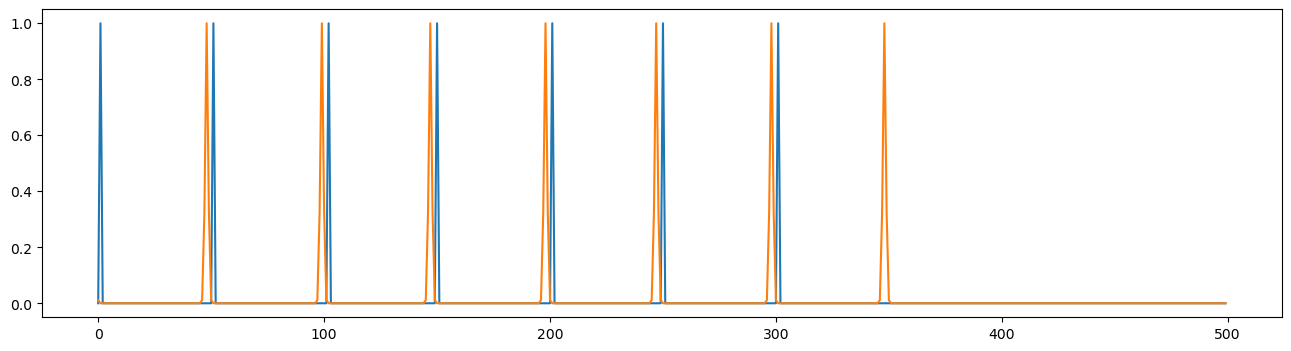

In [194]:
input_seq, target_seq, last_idx = generate_beat_sequence_gaussian_with_noise(**variables)

plt.figure(figsize=(16, 4))
plt.plot(input_seq)

# plt.figure()
plt.plot(target_seq)
display(np.sum(input_seq > 0))
display(last_idx)

In [195]:
target_seq[np.where(input_seq > 0)[0]]

array([0., 0., 0., 0., 0., 0., 0.])

In [196]:
np.diff(np.where(input_seq > 0))

array([[50, 51, 48, 51, 49, 51]])